# Interactive Heterogeneous Random-Line Network

This notebook builds an intersection-line network, clips it by a DAB-like binary mask, and renders the retained line segments as tubes. The box is intentionally flat: the lateral size follows the heterogeneity scale, while the thickness follows the line-wave scale.

In [1]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

import rw_line_network as rln

rln = importlib.reload(rln)
print("PyVista", pv.__version__)

PyVista 0.44.0


## Parameter Settings

In [2]:
# Reproducibility
RANDOM_SEED = 12345

# Line-wave field. The retained curves are intersections of two independent
# zero-level random-wave fields with nominal wave number K_LINE.
K_LINE = 10.0
NUM_LINE_MODES = 128

# DAB-like mask. The real-space two-phase profile used for reference is
# S2(r) = phi^2 + phi(1 - phi) exp(-r / xi_DAB).
K_H = 1
XI_DAB = 1.0 / K_H
MASK_VOLUME_FRACTION = 0.8

# Efficient flat-box geometry: wide in the mask plane, thin along z.
LATERAL_SIZE = 20 / K_H
THICKNESS = 1 / K_H
NX = 160
NY = 160
NZ = 10

# Rendering controls
LINE_TUBE_RADIUS = 0.002 * LATERAL_SIZE
LINE_TUBE_COLOR = rln.SLACK_RED
LINE_TUBE_OPACITY = 1.0
SMOOTH_RETAINED_LINES = True
VORTEX_SMOOTHING_SCALE = 2
VORTEX_SPLINE_SMOOTHING = None
MIN_RETAINED_LINE_LENGTH_OVER_K = 10
MASK_BOUNDARY_OPACITY = 1.0
MASK_BOUNDARY_COLOR = "#666666"
SHOW_MASK_BOUNDARY = True
SHOW_BOX_BOUNDARY = True
SHOW_REJECTED_LINES = False
ENABLE_AMBIENT_OCCLUSION = True
AMBIENT_OCCLUSION_RADIUS = 0.18 * LATERAL_SIZE
AMBIENT_OCCLUSION_BIAS = 0.01

# "edge" looks perpendicular to the flat-plane normal, as requested.
# Change to "normal" for a top-down view along the flat-plane normal.
INITIAL_VIEW = "normal"
WINDOW_SIZE = (800, 800)
WINDOW_FILL_FRACTION = 0.95
ENABLE_ANTI_ALIASING = True
ANTI_ALIASING_MODE = "ssaa"  # Options commonly supported by PyVista: "ssaa", "msaa", "fxaa".
SCREENSHOT_SCALE = 3
SCREENSHOT_PATH = "interactive_rw_hetero_view.png"

print(f"box = {LATERAL_SIZE:.3g} x {LATERAL_SIZE:.3g} x {THICKNESS:.3g}")
print(f"grid = {NX} x {NY} x {NZ}")

box = 20 x 20 x 1
grid = 160 x 160 x 10


In [3]:
def make_coordinates(nx, ny, nz, lx, ly, lz):
    x = np.linspace(-0.5 * lx, 0.5 * lx, nx)
    y = np.linspace(-0.5 * ly, 0.5 * ly, ny)
    z = np.linspace(-0.5 * lz, 0.5 * lz, nz)
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    return x, y, z, X, Y, Z


def sample_isotropic_k_vectors(num_modes, k0, rng):
    directions = rng.normal(size=(num_modes, 3))
    directions /= np.linalg.norm(directions, axis=1)[:, None]
    return k0 * directions


def random_wave_field(X, Y, Z, k_vectors, rng):
    phases = rng.uniform(0.0, 2.0 * np.pi, size=len(k_vectors))
    field = np.zeros_like(X, dtype=float)
    for (kx, ky, kz), phase in zip(k_vectors, phases):
        field += np.cos(kx * X + ky * Y + kz * Z + phase)
    field *= np.sqrt(2.0 / len(k_vectors))
    field -= np.mean(field)
    std = np.std(field)
    if std > 0:
        field /= std
    return field


def dab_filtered_gaussian_field(shape, spacing, xi, rng):
    """Generate a smooth Gaussian mask field with DAB-like spectral envelope."""
    nx, ny, nz = shape
    dx, dy, dz = spacing
    white = rng.normal(size=shape)
    kx = 2.0 * np.pi * np.fft.fftfreq(nx, d=dx)
    ky = 2.0 * np.pi * np.fft.fftfreq(ny, d=dy)
    kz = 2.0 * np.pi * np.fft.fftfreq(nz, d=dz)
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")
    k2 = KX**2 + KY**2 + KZ**2
    # Fourier transform of exp(-r/xi) in 3D is proportional to
    # (1 + k^2 xi^2)^(-2). Filtering white noise by its square root gives
    # a continuous Gaussian field with this target covariance envelope.
    spectral_density = 1.0 / (1.0 + k2 * xi**2) ** 2
    spectral_density[0, 0, 0] = 0.0
    filtered = np.fft.ifftn(np.fft.fftn(white) * np.sqrt(spectral_density)).real
    filtered -= np.mean(filtered)
    std = np.std(filtered)
    if std > 0:
        filtered /= std
    return filtered


def binary_mask_from_fraction(mask_field, volume_fraction):
    threshold = np.quantile(mask_field, 1.0 - volume_fraction)
    return mask_field >= threshold, float(threshold)


def vtk_image_from_array(values, lx, ly, lz):
    nx, ny, nz = values.shape
    grid = pv.ImageData()
    grid.dimensions = (nx, ny, nz)
    grid.origin = (-0.5 * lx, -0.5 * ly, -0.5 * lz)
    grid.spacing = (lx / (nx - 1), ly / (ny - 1), lz / (nz - 1))
    grid.point_data["values"] = np.asarray(values, dtype=float).ravel(order="F")
    return grid


def filter_segments_by_mask(index_poly, mask):
    if index_poly.n_points == 0 or index_poly.lines.size == 0:
        return pv.PolyData(), pv.PolyData()
    points = np.asarray(index_poly.points, dtype=float)
    lines = np.asarray(index_poly.lines, dtype=np.int64)
    kept_points, kept_lines = [], []
    rejected_points, rejected_lines = [], []

    def append_segment(target_points, target_lines, p0, p1):
        base = len(target_points)
        target_points.extend([p0, p1])
        target_lines.extend([2, base, base + 1])

    cursor = 0
    nx, ny, nz = mask.shape
    while cursor < len(lines):
        n = int(lines[cursor])
        ids = lines[cursor + 1 : cursor + 1 + n]
        cursor += n + 1
        if n < 2:
            continue
        for i0, i1 in zip(ids[:-1], ids[1:]):
            p0 = points[int(i0)]
            p1 = points[int(i1)]
            mid = 0.5 * (p0 + p1)
            ix = int(np.clip(np.rint(mid[0]), 0, nx - 1))
            iy = int(np.clip(np.rint(mid[1]), 0, ny - 1))
            iz = int(np.clip(np.rint(mid[2]), 0, nz - 1))
            if mask[ix, iy, iz]:
                append_segment(kept_points, kept_lines, p0, p1)
            else:
                append_segment(rejected_points, rejected_lines, p0, p1)

    def build(points_list, lines_list):
        if not points_list:
            return pv.PolyData()
        poly = pv.PolyData(np.asarray(points_list, dtype=float))
        poly.lines = np.asarray(lines_list, dtype=np.int64)
        return poly

    return build(kept_points, kept_lines), build(rejected_points, rejected_lines)


def line_cell_count(poly):
    lines = np.asarray(getattr(poly, "lines", np.array([], dtype=np.int64)), dtype=np.int64)
    count = 0
    cursor = 0
    while cursor < len(lines):
        n = int(lines[cursor])
        count += 1
        cursor += n + 1
    return count


def has_line_cells(poly):
    return line_cell_count(poly) > 0


def prune_short_line_cells(poly, min_length):
    if min_length <= 0.0 or not has_line_cells(poly):
        return poly
    raw_points = np.asarray(poly.points, dtype=float)
    raw_lines = np.asarray(poly.lines, dtype=np.int64)
    points = []
    lines = []
    cursor = 0
    while cursor < len(raw_lines):
        n = int(raw_lines[cursor])
        ids = raw_lines[cursor + 1 : cursor + 1 + n]
        cursor += n + 1
        if n < 2:
            continue
        path = raw_points[ids]
        length = float(np.sum(np.linalg.norm(np.diff(path, axis=0), axis=1)))
        if length < min_length:
            continue
        start = len(points)
        points.extend(path)
        lines.extend([n, *range(start, start + n)])
    if not points:
        return pv.PolyData()
    out = pv.PolyData(np.asarray(points, dtype=float))
    out.lines = np.asarray(lines, dtype=np.int64)
    return out


def index_poly_to_physical(index_poly, lx, ly, lz, shape):
    if index_poly.n_points == 0:
        return pv.PolyData()
    nx, ny, nz = shape
    poly = index_poly.copy(deep=True)
    pts = np.asarray(poly.points, dtype=float).copy()
    pts[:, 0] = pts[:, 0] / (nx - 1) * lx - 0.5 * lx
    pts[:, 1] = pts[:, 1] / (ny - 1) * ly - 0.5 * ly
    pts[:, 2] = pts[:, 2] / (nz - 1) * lz - 0.5 * lz
    poly.points = pts
    return poly


def set_flat_camera(plotter, lx, ly, lz, view="edge", window_size=(1000, 1000), fill_fraction=0.95):
    aspect = float(window_size[0]) / float(window_size[1])
    fill_fraction = float(np.clip(fill_fraction, 0.05, 1.0))
    if view == "normal":
        plotter.camera_position = [(0.0, 0.0, 3.0 * max(lx, ly)), (0.0, 0.0, 0.0), (0.0, 1.0, 0.0)]
        scale = max(0.5 * ly / fill_fraction, 0.5 * lx / (aspect * fill_fraction))
    else:
        plotter.camera_position = [(0.0, -2.4 * ly, 0.35 * lz), (0.0, 0.0, 0.0), (0.0, 0.0, 1.0)]
        scale = max(0.5 * lz / fill_fraction, 0.5 * lx / (aspect * fill_fraction))
    plotter.enable_parallel_projection()
    plotter.camera.parallel_projection = True
    plotter.camera.parallel_scale = scale
    plotter.camera.SetParallelProjection(True)
    plotter.camera.SetParallelScale(scale)
    plotter.reset_camera_clipping_range()
    return scale


def apply_ambient_occlusion(plotter, radius, bias=0.01, enabled=True):
    if not enabled:
        return False
    renderer = plotter.renderer
    try:
        renderer.UseSSAOOn()
        renderer.SetSSAORadius(float(radius))
        renderer.SetSSAOBias(float(bias))
        return True
    except AttributeError:
        try:
            renderer.enable_ssao(radius=float(radius), bias=float(bias))
            return True
        except AttributeError:
            print("[status] ambient occlusion is not available in this PyVista/VTK build")
            return False


def apply_anti_aliasing(plotter, mode="ssaa", enabled=True):
    if not enabled:
        return False
    try:
        plotter.enable_anti_aliasing(str(mode).lower())
        return True
    except Exception as exc:
        print(f"[status] anti-aliasing mode {mode!r} was not enabled: {exc}")
        return False


def dab_s2_profile(r_values, phi, xi):
    return phi**2 + phi * (1.0 - phi) * np.exp(-r_values / xi)

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
x, y, z, X, Y, Z = make_coordinates(NX, NY, NZ, LATERAL_SIZE, LATERAL_SIZE, THICKNESS)
spacing = (x[1] - x[0], y[1] - y[0], z[1] - z[0])

line_k1 = sample_isotropic_k_vectors(NUM_LINE_MODES, K_LINE, rng)
line_k2 = sample_isotropic_k_vectors(NUM_LINE_MODES, K_LINE, rng)
psi1 = random_wave_field(X, Y, Z, line_k1, rng)
psi2 = random_wave_field(X, Y, Z, line_k2, rng)

mask_field = dab_filtered_gaussian_field((NX, NY, NZ), spacing, XI_DAB, rng)
mask, mask_threshold = binary_mask_from_fraction(mask_field, MASK_VOLUME_FRACTION)

line_index = rln.trace_vortex_segments(psi1, psi2)
kept_index, rejected_index = filter_segments_by_mask(line_index, mask)
line_poly_raw = index_poly_to_physical(kept_index, LATERAL_SIZE, LATERAL_SIZE, THICKNESS, mask.shape)
rejected_poly_raw = index_poly_to_physical(rejected_index, LATERAL_SIZE, LATERAL_SIZE, THICKNESS, mask.shape)

rln.SMOOTH_VORTEX_LINES = bool(SMOOTH_RETAINED_LINES)
rln.VORTEX_SMOOTHING_SCALE = int(VORTEX_SMOOTHING_SCALE)
rln.VORTEX_SPLINE_SMOOTHING = VORTEX_SPLINE_SMOOTHING
line_poly = rln.smooth_vortex_polydata(line_poly_raw) if has_line_cells(line_poly_raw) else line_poly_raw
rejected_poly = rln.smooth_vortex_polydata(rejected_poly_raw) if has_line_cells(rejected_poly_raw) else rejected_poly_raw
min_retained_line_length = float(MIN_RETAINED_LINE_LENGTH_OVER_K) / float(K_LINE)
line_poly = prune_short_line_cells(line_poly, min_retained_line_length)

tube = line_poly.tube(radius=LINE_TUBE_RADIUS, n_sides=14) if has_line_cells(line_poly) else pv.PolyData()
rejected_tube = rejected_poly.tube(radius=0.55 * LINE_TUBE_RADIUS, n_sides=10) if has_line_cells(rejected_poly) else pv.PolyData()

mask_grid = vtk_image_from_array(mask_field, LATERAL_SIZE, LATERAL_SIZE, THICKNESS)
mask_boundary = mask_grid.contour([mask_threshold], scalars="values")

print(f"requested mask volume fraction = {MASK_VOLUME_FRACTION:.3f}")
print(f"realized mask volume fraction  = {mask.mean():.3f}")
print(f"mask threshold = {mask_threshold:.4g}")
print(f"raw line segments = {line_index.n_cells:,}")
print(f"retained segments = {line_cell_count(kept_index):,}")
print(f"rejected segments = {line_cell_count(rejected_index):,}")
print(f"minimum retained line length = {min_retained_line_length:.4g}")
print(f"smoothed retained points = {line_poly.n_points:,}")
print(f"retained tube points = {tube.n_points:,}")
if line_cell_count(kept_index) == 0:
    print("[status] no retained line segments; try increasing MASK_VOLUME_FRACTION, LATERAL_SIZE, or NUM_LINE_MODES")

requested mask volume fraction = 0.800
realized mask volume fraction  = 0.800
mask threshold = -0.8701
raw line segments = 52,980
retained segments = 42,249
rejected segments = 10,731
minimum retained line length = 1
smoothed retained points = 61,990
retained tube points = 899,668


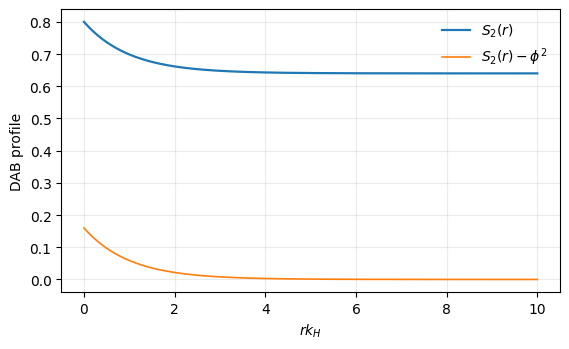

In [5]:
r_profile = np.linspace(0.0, 0.5 * LATERAL_SIZE, 300)
s2_profile = dab_s2_profile(r_profile, MASK_VOLUME_FRACTION, XI_DAB)
contrast_profile = s2_profile - MASK_VOLUME_FRACTION**2

fig, ax = plt.subplots(figsize=(5.8, 3.6))
ax.plot(r_profile * K_H, s2_profile, lw=1.6, label=r"$S_2(r)$")
ax.plot(r_profile * K_H, contrast_profile, lw=1.2, label=r"$S_2(r)-\phi^2$")
ax.set_xlabel(r"$r k_H$")
ax.set_ylabel("DAB profile")
ax.legend(frameon=False)
ax.grid(True, alpha=0.25)
fig.tight_layout()

In [6]:
plotter = pv.Plotter(window_size=WINDOW_SIZE)
plotter.set_background("white")
aa_enabled = apply_anti_aliasing(plotter, ANTI_ALIASING_MODE, ENABLE_ANTI_ALIASING)
print(f"anti-aliasing enabled = {aa_enabled} ({ANTI_ALIASING_MODE})")

if SHOW_MASK_BOUNDARY and mask_boundary.n_points:
    plotter.add_mesh(
        mask_boundary,
        color=MASK_BOUNDARY_COLOR,
        opacity=MASK_BOUNDARY_OPACITY,
        smooth_shading=True,
        label="mask boundary",
    )

if SHOW_REJECTED_LINES and rejected_tube.n_points:
    plotter.add_mesh(
        rejected_tube,
        color="#c7c7c7",
        opacity=0.16,
        smooth_shading=True,
        show_edges=False,
        specular=0.18,
        label="outside mask",
    )

if tube.n_points:
    plotter.add_mesh(
        tube,
        color=LINE_TUBE_COLOR,
        opacity=LINE_TUBE_OPACITY,
        smooth_shading=True,
        show_edges=False,
        edge_color=rln.TUBE_EDGE_COLOR,
        specular=0.25,
        label="retained line",
        name="retained_line",
    )

if SHOW_BOX_BOUNDARY:
    box = pv.Box(bounds=(-0.5 * LATERAL_SIZE, 0.5 * LATERAL_SIZE, -0.5 * LATERAL_SIZE, 0.5 * LATERAL_SIZE, -0.5 * THICKNESS, 0.5 * THICKNESS))
    plotter.add_mesh(box, style="wireframe", color="#555555", line_width=1.0, opacity=0.55)

plotter.add_light(pv.Light(position=(0.0, -2.0 * LATERAL_SIZE, 1.2 * LATERAL_SIZE), focal_point=(0.0, 0.0, 0.0), intensity=0.9))
plotter.add_light(pv.Light(position=(1.2 * LATERAL_SIZE, 1.0 * LATERAL_SIZE, 0.8 * LATERAL_SIZE), focal_point=(0.0, 0.0, 0.0), intensity=0.45))
ao_enabled = apply_ambient_occlusion(
    plotter,
    AMBIENT_OCCLUSION_RADIUS,
    AMBIENT_OCCLUSION_BIAS,
    ENABLE_AMBIENT_OCCLUSION,
)
print(f"ambient occlusion enabled = {ao_enabled}")
camera_parallel_scale = set_flat_camera(
    plotter,
    LATERAL_SIZE,
    LATERAL_SIZE,
    THICKNESS,
    INITIAL_VIEW,
    WINDOW_SIZE,
    WINDOW_FILL_FRACTION,
)
print(f"camera parallel scale = {camera_parallel_scale:.4g}")
plotter

anti-aliasing enabled = True (ssaa)
ambient occlusion enabled = True
camera parallel scale = 10.53


In [7]:
pv.set_jupyter_backend("html")
set_flat_camera(plotter, LATERAL_SIZE, LATERAL_SIZE, THICKNESS, INITIAL_VIEW, WINDOW_SIZE, WINDOW_FILL_FRACTION)
plotter.show(jupyter_backend="html")

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [8]:
# Native-window fallback. Run this cell locally if the HTML backend is slow.
# pv.set_jupyter_backend("none")
# plotter.show()

In [9]:
# Optional still image export. The scale factor supersamples the saved image,
# which is usually the most reliable way to reduce jagged tube edges.
set_flat_camera(plotter, LATERAL_SIZE, LATERAL_SIZE, THICKNESS, INITIAL_VIEW, WINDOW_SIZE, WINDOW_FILL_FRACTION)
plotter.screenshot(
    SCREENSHOT_PATH,
    transparent_background=False,
    scale=SCREENSHOT_SCALE,
)
print(f"saved {SCREENSHOT_PATH} at {SCREENSHOT_SCALE}x supersampling")

saved interactive_rw_hetero_view.png at 3x supersampling
